In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import json

In [28]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [29]:
train_df = pd.read_csv('train_processed.csv', parse_dates=['Date'])
test_df  = pd.read_csv('test_processed.csv',  parse_dates=['Date'])

In [30]:
drop_cols = ['Date', 'Sales', 'YearMont']

feature_cols = [c for c in train_df.columns if c not in drop_cols]
target_col = 'Sales'


X_train = train_df[feature_cols]
y_train = train_df['Sales']

X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

print(f"Features: {len(feature_cols)}")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2}. {col}")

Features: 31
X_train : (767320, 31)
X_test  : (45852, 31)

Feature list:
   1. Store
   2. DayOfWeek
   3. Promo
   4. SchoolHoliday
   5. StoreType
   6. Assortment
   7. CompetitionDistance
   8. Promo2
   9. Year
  10. Month
  11. Week
  12. IsHoliday
  13. DayOfMonth
  14. Quarter
  15. IsWeekend
  16. DaysTillMonthEnd
  17. IsMonthStart
  18. IsMonthEnd
  19. lag_1
  20. lag_7
  21. lag_14
  22. lag_28
  23. rolling_mean_7
  24. rolling_std_7
  25. rolling_max_7
  26. rolling_mean_14
  27. rolling_std_14
  28. rolling_max_14
  29. rolling_mean_28
  30. rolling_std_28
  31. rolling_max_28


In [31]:
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

print(f"\nBest iteration: {xgb_model.best_iteration}")
print(f"Best RMSE     : {xgb_model.best_score:.4f}")

[0]	validation_0-rmse:2992.40625	validation_1-rmse:2965.90352
[100]	validation_0-rmse:994.73773	validation_1-rmse:956.94260
[200]	validation_0-rmse:917.52496	validation_1-rmse:915.18806
[300]	validation_0-rmse:887.65597	validation_1-rmse:903.48583
[400]	validation_0-rmse:866.90107	validation_1-rmse:898.98046
[500]	validation_0-rmse:848.07901	validation_1-rmse:893.33040
[600]	validation_0-rmse:832.16770	validation_1-rmse:884.18628
[700]	validation_0-rmse:819.41679	validation_1-rmse:878.60689
[800]	validation_0-rmse:809.62863	validation_1-rmse:876.60001
[839]	validation_0-rmse:805.06457	validation_1-rmse:878.69362

Best iteration: 789
Best RMSE     : 876.1782


In [32]:
def mape(actual, predicted):
  actual, predicted = np.array(actual), np.array(predicted)
  mask = actual !=0
  return np.mean(np.abs((actual[mask] - predicted[mask])) * 100/actual[mask])

preds = xgb_model.predict(X_test)
preds = np.clip(preds, 0, None)

mae      = mean_absolute_error(y_test, preds)
rmse     = np.sqrt(mean_squared_error(y_test, preds))
mape_val = mape(y_test, preds)

In [33]:
print("=" * 45)
print("XGBoost — All 1115 Stores Performance")
print("=" * 45)
print(f"  MAE  : {mae:,.2f}")
print(f"  RMSE : {rmse:,.2f}")
print(f"  MAPE : {mape_val:.2f}%")
print("=" * 45)

xgb_metrics = {'Model': 'XGBoost', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape_val}

XGBoost — All 1115 Stores Performance
  MAE  : 615.42
  RMSE : 876.18
  MAPE : 9.23%


In [34]:
test_results = test_df[['Date', 'Store', 'Sales', 'StoreType']].copy()
test_results['Predicted'] = preds
test_results['APE'] = np.abs(
    (test_results['Sales'] - test_results['Predicted']) / test_results['Sales']) * 100


store_mape = test_results.groupby('Store')['APE'].mean().reset_index()
store_mape.columns = ['Store', 'MAPE']
store_mape = store_mape.sort_values('MAPE')

print(f"Median store MAPE : {store_mape['MAPE'].median():.2f}%")
print(f"Best store MAPE   : {store_mape['MAPE'].min():.2f}%")
print(f"Worst store MAPE  : {store_mape['MAPE'].max():.2f}%")
print(f"Stores under 10%  : {(store_mape['MAPE'] < 10).sum()} / {len(store_mape)}")
print(f"Stores under 15%  : {(store_mape['MAPE'] < 15).sum()} / {len(store_mape)}")

Median store MAPE : 8.77%
Best store MAPE   : 4.65%
Worst store MAPE  : 87.38%
Stores under 10%  : 776 / 1115
Stores under 15%  : 1088 / 1115


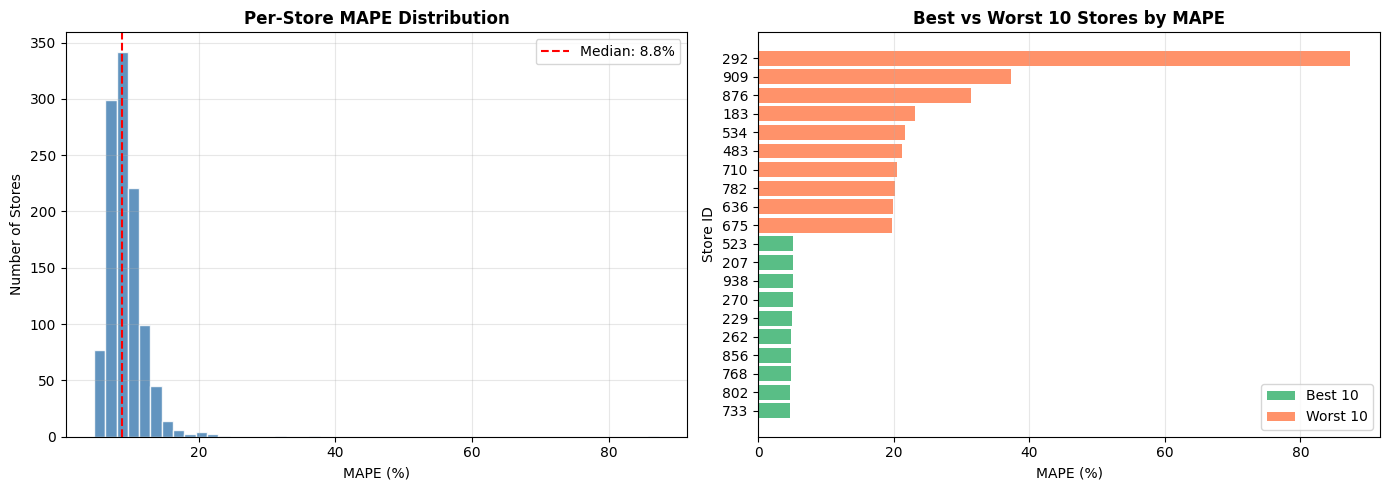

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(store_mape['MAPE'], bins=50, color='steelblue',
             alpha=0.85, edgecolor='white')
axes[0].axvline(store_mape['MAPE'].median(), color='red',
                linestyle='--', label=f"Median: {store_mape['MAPE'].median():.1f}%")
axes[0].set_title('Per-Store MAPE Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('MAPE (%)')
axes[0].set_ylabel('Number of Stores')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

top10    = store_mape.head(10)
bottom10 = store_mape.tail(10)

axes[1].barh(top10['Store'].astype(str), top10['MAPE'],
             color='mediumseagreen', alpha=0.85, label='Best 10')
axes[1].barh(bottom10['Store'].astype(str), bottom10['MAPE'],
             color='coral', alpha=0.85, label='Worst 10')
axes[1].set_title('Best vs Worst 10 Stores by MAPE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('MAPE (%)')
axes[1].set_ylabel('Store ID')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('01_store_mape_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

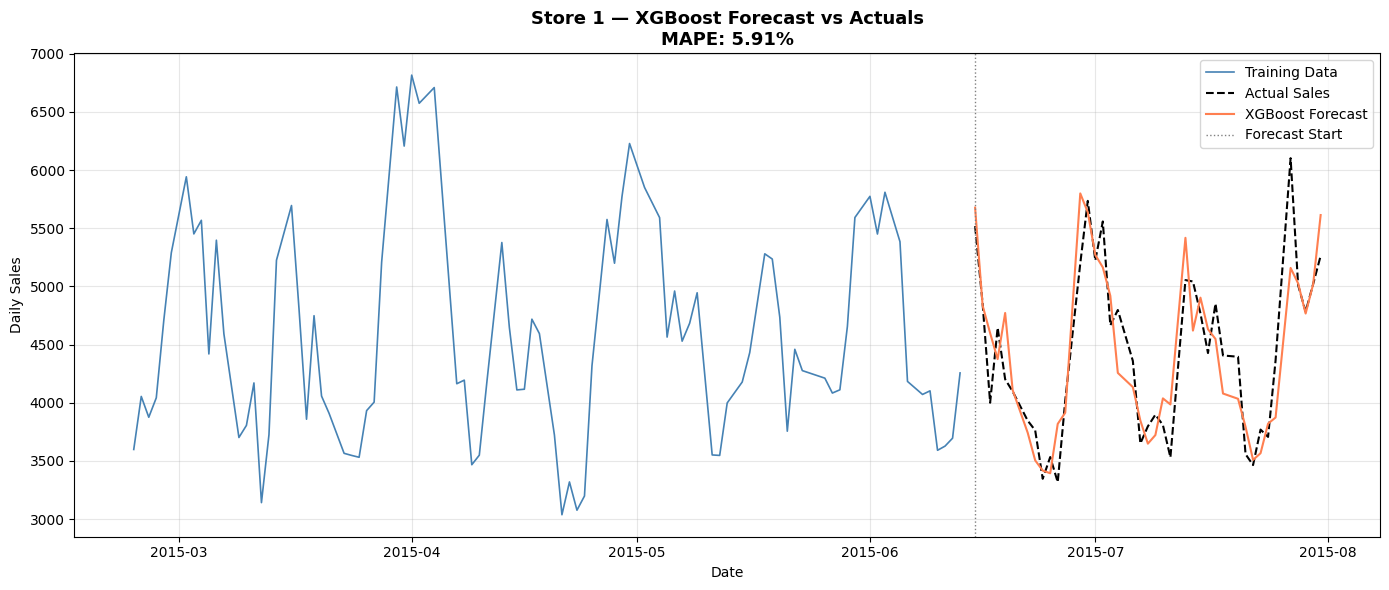

Store 1 XGBoost MAPE: 5.91%


In [36]:
store1_results = test_results[test_results['Store'] == 1].sort_values('Date')
store1_train = train_df[train_df['Store'] == 1].sort_values('Date').tail(90)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(store1_train['Date'], store1_train['Sales'],
        color='steelblue', linewidth=1.2, label='Training Data')

ax.plot(store1_results['Date'], store1_results['Sales'],
        color='black', linewidth=1.5, linestyle='--', label='Actual Sales')

ax.plot(store1_results['Date'], store1_results['Predicted'],
        color='coral', linewidth=1.5, label='XGBoost Forecast')

store1_mape = store1_results['APE'].mean()
ax.axvline(store1_results['Date'].min(), color='gray',
           linestyle=':', linewidth=1, label='Forecast Start')
ax.set_title(f'Store 1 — XGBoost Forecast vs Actuals\nMAPE: {store1_mape:.2f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Sales')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_store1_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Store 1 XGBoost MAPE: {store1_mape:.2f}%")

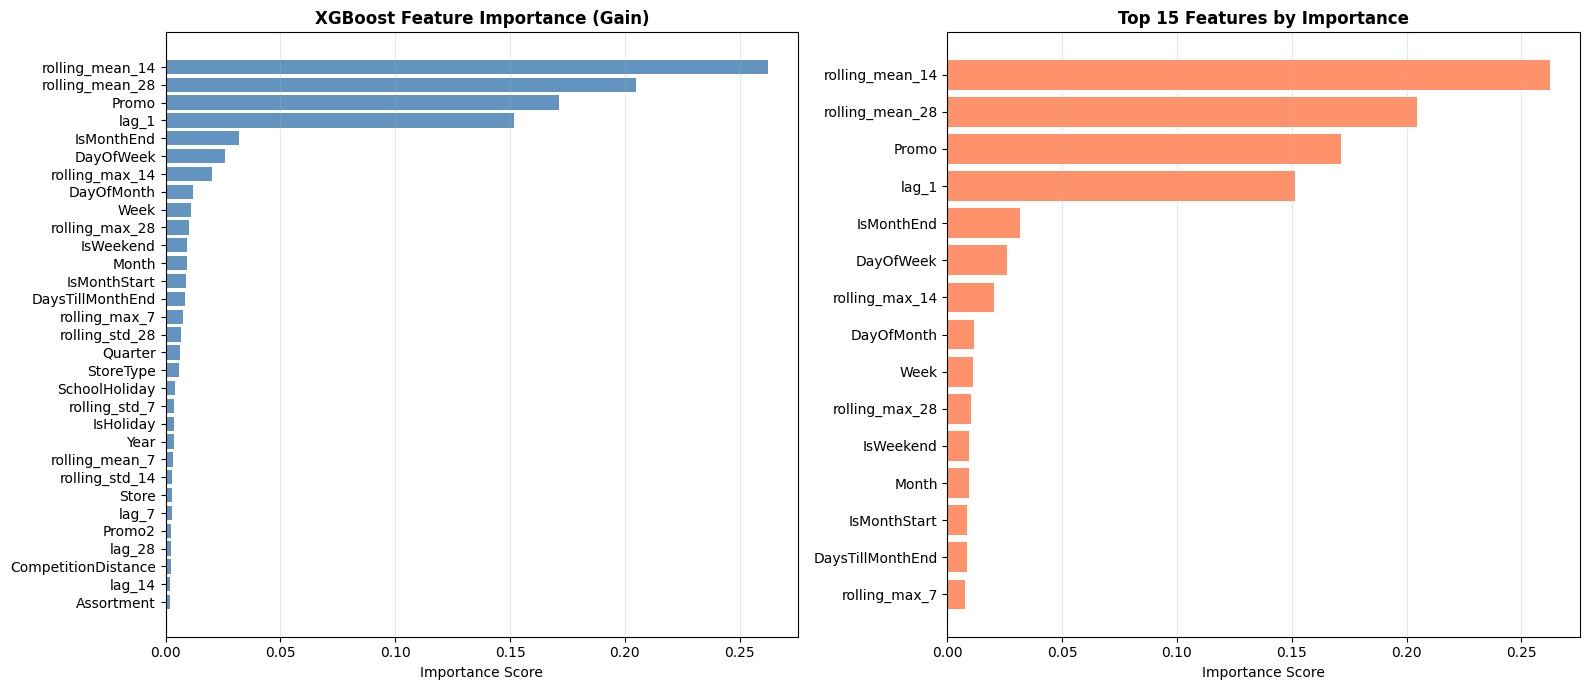


Top 10 features:
        Feature  Importance
rolling_mean_14    0.262412
rolling_mean_28    0.204710
          Promo    0.171485
          lag_1    0.151542
     IsMonthEnd    0.031847
      DayOfWeek    0.025855
 rolling_max_14    0.020329
     DayOfMonth    0.011808
           Week    0.011256
 rolling_max_28    0.010107


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[0].barh(importance_df['Feature'], importance_df['Importance'],
             color='steelblue', alpha=0.85)
axes[0].set_title('XGBoost Feature Importance (Gain)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].grid(True, alpha=0.3, axis='x')

top15 = importance_df.tail(15)
axes[1].barh(top15['Feature'], top15['Importance'],
             color='coral', alpha=0.85)
axes[1].set_title('Top 15 Features by Importance',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
print(importance_df.tail(10)[['Feature', 'Importance']].iloc[::-1].to_string(index=False))

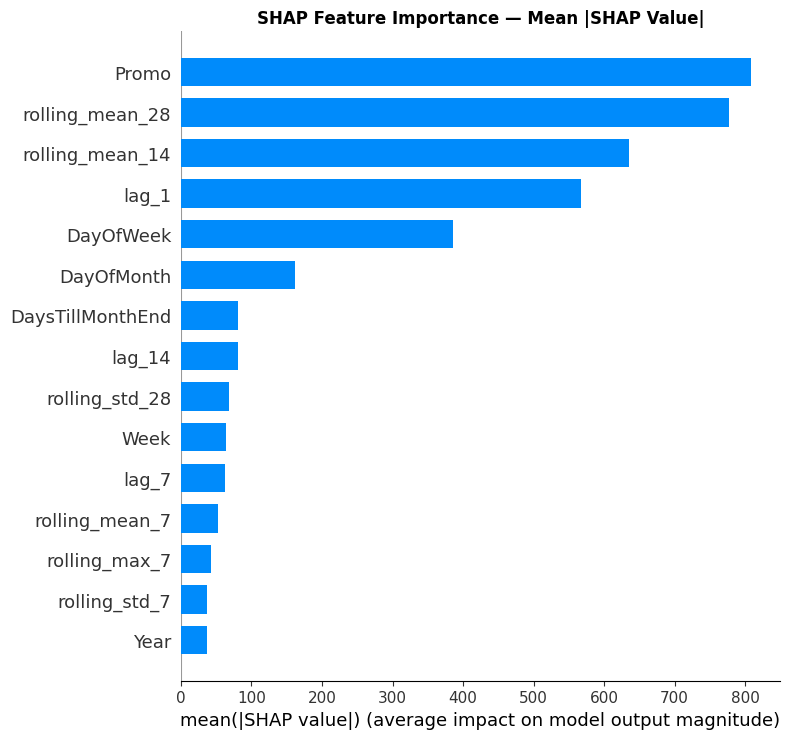

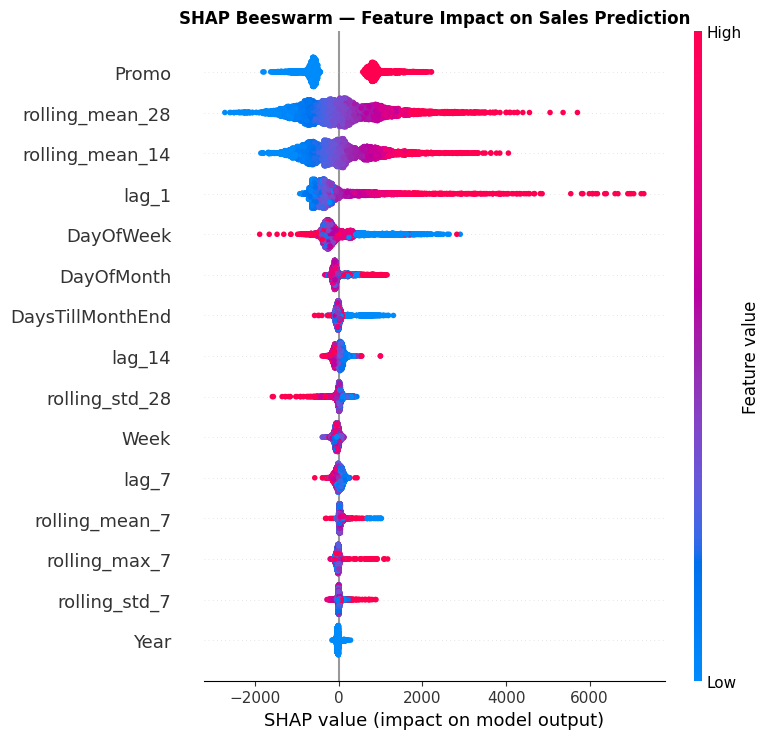

In [38]:
sample_idx = np.random.choice(len(X_test), size=5000, replace=False)
X_sample   = X_test.iloc[sample_idx]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample,
                  plot_type='bar',
                  show=False,
                  max_display=15)
plt.title('SHAP Feature Importance — Mean |SHAP Value|',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('04_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample,
                  show=False,
                  max_display=15)
plt.title('SHAP Beeswarm — Feature Impact on Sales Prediction',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('05_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
with open('xgb_metrics.json', 'w') as f:
    json.dump(xgb_metrics, f)

print("=" * 55)
print("Final Model Comparison")
print("=" * 55)
print(f"{'Model':<12} {'MAE':>10} {'RMSE':>10} {'MAPE':>10}")
print("-" * 55)
print(f"{xgb_metrics['Model']:<12} {xgb_metrics['MAE']:>10,.2f} "
          f"{xgb_metrics['RMSE']:>10,.2f} {xgb_metrics['MAPE']:>10.2f}%")

Final Model Comparison
Model               MAE       RMSE       MAPE
-------------------------------------------------------
XGBoost          615.42     876.18       9.23%


In [40]:
# Check 1 — are lag features actually populated?
print("Lag feature null counts in test:")
lag_cols = ['lag_1', 'lag_7', 'lag_14', 'lag_28']
print(test_df[lag_cols].isnull().sum())

# Check 2 — sales distribution comparison
print(f"\nTrain Sales stats:")
print(train_df['Sales'].describe())
print(f"\nTest Sales stats:")
print(test_df['Sales'].describe())

# Check 3 — prediction range
print(f"\nPrediction range:")
print(f"Min pred : {preds.min():.2f}")
print(f"Max pred : {preds.max():.2f}")
print(f"Mean pred: {preds.mean():.2f}")
print(f"Mean actual: {y_test.mean():.2f}")

# Check 4 — per storetype MAPE
test_results['StoreType'] = test_df['StoreType']
print(f"\nMAPE by StoreType:")
print(test_results.groupby('StoreType')['APE'].mean())

# Check 5 — best iteration used
print(f"\nBest iteration: {xgb_model.best_iteration}")
print(f"Total estimators: {xgb_model.n_estimators}")

Lag feature null counts in test:
lag_1     0
lag_7     0
lag_14    0
lag_28    0
dtype: int64

Train Sales stats:
count    767320.000000
mean       6973.217284
std        3112.706749
min           0.000000
25%        4871.000000
50%        6384.000000
75%        8380.000000
max       38722.000000
Name: Sales, dtype: float64

Test Sales stats:
count    45852.000000
mean      7144.474243
std       3089.192127
min        569.000000
25%       5053.000000
50%       6564.000000
75%       8575.250000
max      41551.000000
Name: Sales, dtype: float64

Prediction range:
Min pred : 824.91
Max pred : 30181.66
Mean pred: 7158.23
Mean actual: 7144.47

MAPE by StoreType:
StoreType
0.0    8.940718
1.0    6.585124
2.0    8.354530
Name: APE, dtype: float64

Best iteration: 789
Total estimators: 1000


In [42]:
# Store 1 only evaluation
store1_test = test_results[test_results['Store'] == 1].copy()

store1_mae  = mean_absolute_error(store1_test['Sales'], store1_test['Predicted'])
store1_rmse = np.sqrt(mean_squared_error(store1_test['Sales'], store1_test['Predicted']))
store1_mape = store1_test['APE'].mean()

print("=" * 55)
print("Fair Comparison — Store 1 Only")
print("=" * 55)
print(f"{'Model':<12} {'MAE':>10} {'RMSE':>10} {'MAPE':>10}")
print("-" * 55)
print(f"{'SARIMA':<12} {378.72:>10,.2f} {403.39:>10,.2f} {8.49:>10.2f}%")
print(f"{'Prophet':<12} {344.91:>10,.2f} {443.65:>10,.2f} {7.96:>10.2f}%")
print(f"{'XGBoost':<12} {store1_mae:>10,.2f} {store1_rmse:>10,.2f} {store1_mape:>10.2f}%")
print("=" * 55)

# Update xgb metrics with all-store context noted
xgb_metrics_store1 = {
    'Model': 'XGBoost (Store 1)',
    'MAE': store1_mae,
    'RMSE': store1_rmse,
    'MAPE': store1_mape
}

xgb_metrics_all = {
    'Model': 'XGBoost (All Stores)',
    'MAE': 615.42,
    'RMSE': 876.18,
    'MAPE': 9.23
}

print("\nNote:")
print(f"  XGBoost all-store MAPE : 9.23% across 1115 stores")
print(f"  XGBoost Store 1 MAPE   : {store1_mape:.2f}% (fair comparison)")
print(f"  Stores under 10% MAPE  : {(store_mape['MAPE'] < 10).sum()} / {len(store_mape)}")

Fair Comparison — Store 1 Only
Model               MAE       RMSE       MAPE
-------------------------------------------------------
SARIMA           378.72     403.39       8.49%
Prophet          344.91     443.65       7.96%
XGBoost          260.96     331.24       5.91%

Note:
  XGBoost all-store MAPE : 9.23% across 1115 stores
  XGBoost Store 1 MAPE   : 5.91% (fair comparison)
  Stores under 10% MAPE  : 776 / 1115
